# Walk-Forward Splitter — Visual Walkthrough

Synthetic dataset: **64 strategies × 72 five-minute bars × every trading day Jan 2021 → May 2026**

Protocol:
- **Rolling** training window (252 days constant — no expanding)
- **1-day purge** between last training day and first prediction day
- **Refit every 21 trading days** (~monthly)
- Stage 1 OOS (model selection): 2023-01-01 → 2025-06-30
- Stage 2 OOS (final eval):       2025-07-01 → 2026-05-30  ← never touched until the end

Three plots:
1. Full timeline — burn-in / Stage 1 / Stage 2 with refit markers and flat rolling train-window size
2. Rolling windows — 12 refit steps showing constant-width bars sliding forward + purge strip
3. Refit cycle zoom — two consecutive refits showing exactly what the model sees and predicts

In [2]:
import sys, os
sys.path.insert(0, '../code')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

from ml_protocol import SplitConfig, TimeSeriesSplitter

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ── Protocol parameters ────────────────────────────────────────────────────────
DATA_START   = pd.Timestamp('2022-04-04')   # synthetic start (more burn-in)
DATA_END     = pd.Timestamp('2026-05-30')
OOS_START    = pd.Timestamp('2023-01-02')   # Stage 1 begins
STAGE2_START = pd.Timestamp('2025-07-01')   # Stage 2 begins — never touch until the end

N_STRATS       = 64
N_BARS         = 72    # 5-min bars per trading day (9:30 → 16:00)
RPD            = N_STRATS * N_BARS   # rows per day
REFIT_EVERY    = 21
PURGE_DAYS     = 1
ROLLING_WINDOW = 252

cfg = SplitConfig(
    min_train_days  = ROLLING_WINDOW,
    oos_start_date  = OOS_START,
    refit_every     = REFIT_EVERY,
    purge_days      = PURGE_DAYS,
    window_type     = 'rolling',
    rolling_window  = ROLLING_WINDOW,
    val_fraction    = 0.26,
    verbose         = True,

)
splitter = TimeSeriesSplitter(cfg)

print(f'Dataset: {DATA_START.date()} → {DATA_END.date()}')
print(f'Panel  : {N_STRATS} strats × {N_BARS} bars/day = {RPD:,} rows/day')
print(f'Protocol: rolling {ROLLING_WINDOW}d train | {PURGE_DAYS}d purge | refit every {REFIT_EVERY}d')

Dataset: 2022-04-04 → 2026-05-30
Panel  : 64 strats × 72 bars/day = 4,608 rows/day
Protocol: rolling 252d train | 1d purge | refit every 21d


In [3]:
# ── Generate unique trading dates ─────────────────────────────────────────────
trading_days = pd.bdate_range(DATA_START, DATA_END)
dates_np = trading_days.to_numpy()
total_rows = len(trading_days) * RPD

print(f'Trading days total : {len(trading_days)}')
print(f'Total rows (synth) : {total_rows:,}')

# ── Run splitter — collect split metadata ─────────────────────────────────────
records = []
for train_iloc, test_iloc, is_refit in splitter.split(dates_np):
    test_date   = pd.Timestamp(dates_np[test_iloc[0]])
    train_start = pd.Timestamp(dates_np[train_iloc[0]])
    train_end   = pd.Timestamp(dates_np[train_iloc[-1]])
    # purge = the day(s) between train_end and test_date
    purge_date  = pd.Timestamp(dates_np[test_iloc[0] - 1])  # with purge_days=1
    records.append({
        'test_date'   : test_date,
        'train_start' : train_start,
        'train_end'   : train_end,
        'purge_date'  : purge_date,
        'n_train_days': len(train_iloc),
        'is_refit'    : is_refit,
        'stage'       : 'stage2' if test_date >= STAGE2_START else 'stage1',
    })

df    = pd.DataFrame(records)
refits = df[df['is_refit']].reset_index(drop=True)

print(f'\nSplitter output:')
print(f'  First OOS day  : {df.test_date.min().date()}')
print(f'  OOS days total : {len(df)}')
print(f'  Stage 1        : {(df.stage=="stage1").sum()} days  '
      f'({df[df.stage=="stage1"].test_date.min().date()} → {df[df.stage=="stage1"].test_date.max().date()})')
print(f'  Stage 2        : {(df.stage=="stage2").sum()} days  '
      f'({df[df.stage=="stage2"].test_date.min().date()} → {df[df.stage=="stage2"].test_date.max().date()})')
print(f'  Refit events   : {len(refits)}  (every {REFIT_EVERY} trading days)')
print(f'  Train size     : always {refits.n_train_days.unique()} days  (rolling = constant)')
print(f'\nRows per refit cycle:')
print(f'  Training rows  : {ROLLING_WINDOW} days × {RPD:,} rows/day = {ROLLING_WINDOW*RPD:,}')
print(f'  Purge rows     : {PURGE_DAYS} day  × {RPD:,} rows/day = {PURGE_DAYS*RPD:,}  (skipped)')
print(f'  Predicted rows : {REFIT_EVERY} days × {RPD:,} rows/day = {REFIT_EVERY*RPD:,}')

Trading days total : 1085
Total rows (synth) : 4,999,680
════════════════════════════════════════════════════════════════════════
  TimeSeriesSplitter
  Dataset     : 2022-04-04 → 2026-05-29  (1085 trading days)
  OOS start   : 2023-03-23  (index 253, burn-in = 253 days)
  Train window: 252 days (rolling, constant)
  Purge gap   : 1 trading day(s)
  Refit every : 21 trading days
════════════════════════════════════════════════════════════════════════
  Refit   1  │  train 2022-04-04 → 2023-03-21  (252d)  │  purge 2023-03-22  │  test from 2023-03-23
  Refit   2  │  train 2022-05-03 → 2023-04-19  (252d)  │  purge 2023-04-20  │  test from 2023-04-21
  Refit   3  │  train 2022-06-01 → 2023-05-18  (252d)  │  purge 2023-05-19  │  test from 2023-05-22
  Refit   4  │  train 2022-06-30 → 2023-06-16  (252d)  │  purge 2023-06-19  │  test from 2023-06-20
  Refit   5  │  train 2022-07-29 → 2023-07-17  (252d)  │  purge 2023-07-18  │  test from 2023-07-19
  Refit   6  │  train 2022-08-29 → 2023-08-15

## Plot 1 — Full Timeline

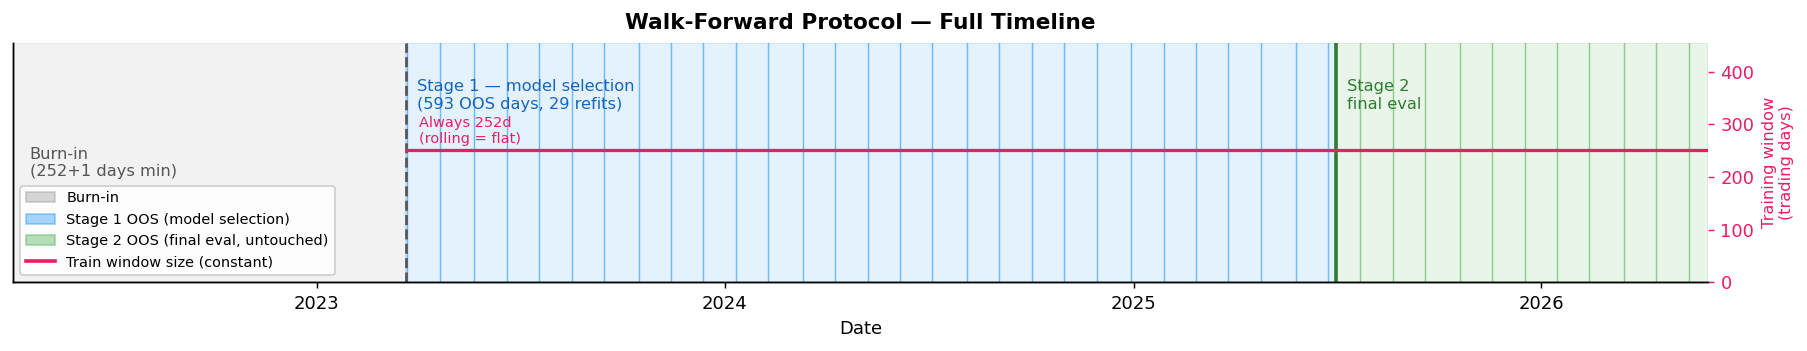

In [4]:
fig, ax = plt.subplots(figsize=(14, 2.8))

# ── Background bands ──────────────────────────────────────────────────────────
burn_end = df.test_date.min() - pd.Timedelta(days=1)
ax.axvspan(DATA_START,    burn_end,     alpha=0.12, color='#999999', zorder=0)
ax.axvspan(burn_end,      STAGE2_START, alpha=0.12, color='#2196F3', zorder=0)
ax.axvspan(STAGE2_START,  DATA_END,     alpha=0.12, color='#4CAF50', zorder=0)

# ── Refit markers ─────────────────────────────────────────────────────────────
for _, row in refits.iterrows():
    color = '#4CAF50' if row.stage == 'stage2' else '#2196F3'
    ax.axvline(row.test_date, color=color, lw=0.8, alpha=0.6, zorder=1)

# ── Rolling train-window size — flat line ─────────────────────────────────────
ax2 = ax.twinx()
ax2.plot(df['test_date'], df['n_train_days'], color='#E91E63', lw=1.8, zorder=3)
ax2.set_ylabel('Training window\n(trading days)', color='#E91E63', fontsize=9)
ax2.tick_params(axis='y', colors='#E91E63')
ax2.spines['top'].set_visible(False)
ax2.set_ylim(0, ROLLING_WINDOW * 1.8)

# ── Boundary lines & labels ───────────────────────────────────────────────────
ax.axvline(burn_end,      color='#555',    lw=1.5, ls='--', zorder=2)
ax.axvline(STAGE2_START,  color='#2E7D32', lw=2,   zorder=2)

ax.text(DATA_START + pd.Timedelta(days=15), 0.5,
        f'Burn-in\n({ROLLING_WINDOW}+{PURGE_DAYS} days min)', va='center', ha='left', fontsize=9, color='#555')
ax.text(burn_end + pd.Timedelta(days=10), 0.85,
        f'Stage 1 — model selection\n({(df.stage=="stage1").sum()} OOS days, {len(refits[refits.stage=="stage1"])} refits)',
        va='top', ha='left', fontsize=9, color='#1565C0')
ax.text(STAGE2_START + pd.Timedelta(days=10), 0.85,
        f'Stage 2\nfinal eval', va='top', ha='left', fontsize=9, color='#2E7D32')
ax2.text(df.test_date.min() + pd.Timedelta(days=10), ROLLING_WINDOW * 1.05,
         f'Always {ROLLING_WINDOW}d\n(rolling = flat)', fontsize=8, color='#E91E63')

ax.set_xlim(DATA_START, DATA_END)
ax.set_ylim(0, 1); ax.set_yticks([])
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlabel('Date')
ax.set_title('Walk-Forward Protocol — Full Timeline', fontsize=12, fontweight='bold', pad=8)
patches = [
    mpatches.Patch(color='#999999', alpha=0.4, label='Burn-in'),
    mpatches.Patch(color='#2196F3', alpha=0.4, label='Stage 1 OOS (model selection)'),
    mpatches.Patch(color='#4CAF50', alpha=0.4, label='Stage 2 OOS (final eval, untouched)'),
    plt.Line2D([0],[0], color='#E91E63', lw=2, label='Train window size (constant)'),
]
ax.legend(handles=patches, loc='lower left', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('../output/figures/splitter_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2 — All Refit Steps (Stage 1 + Stage 2)

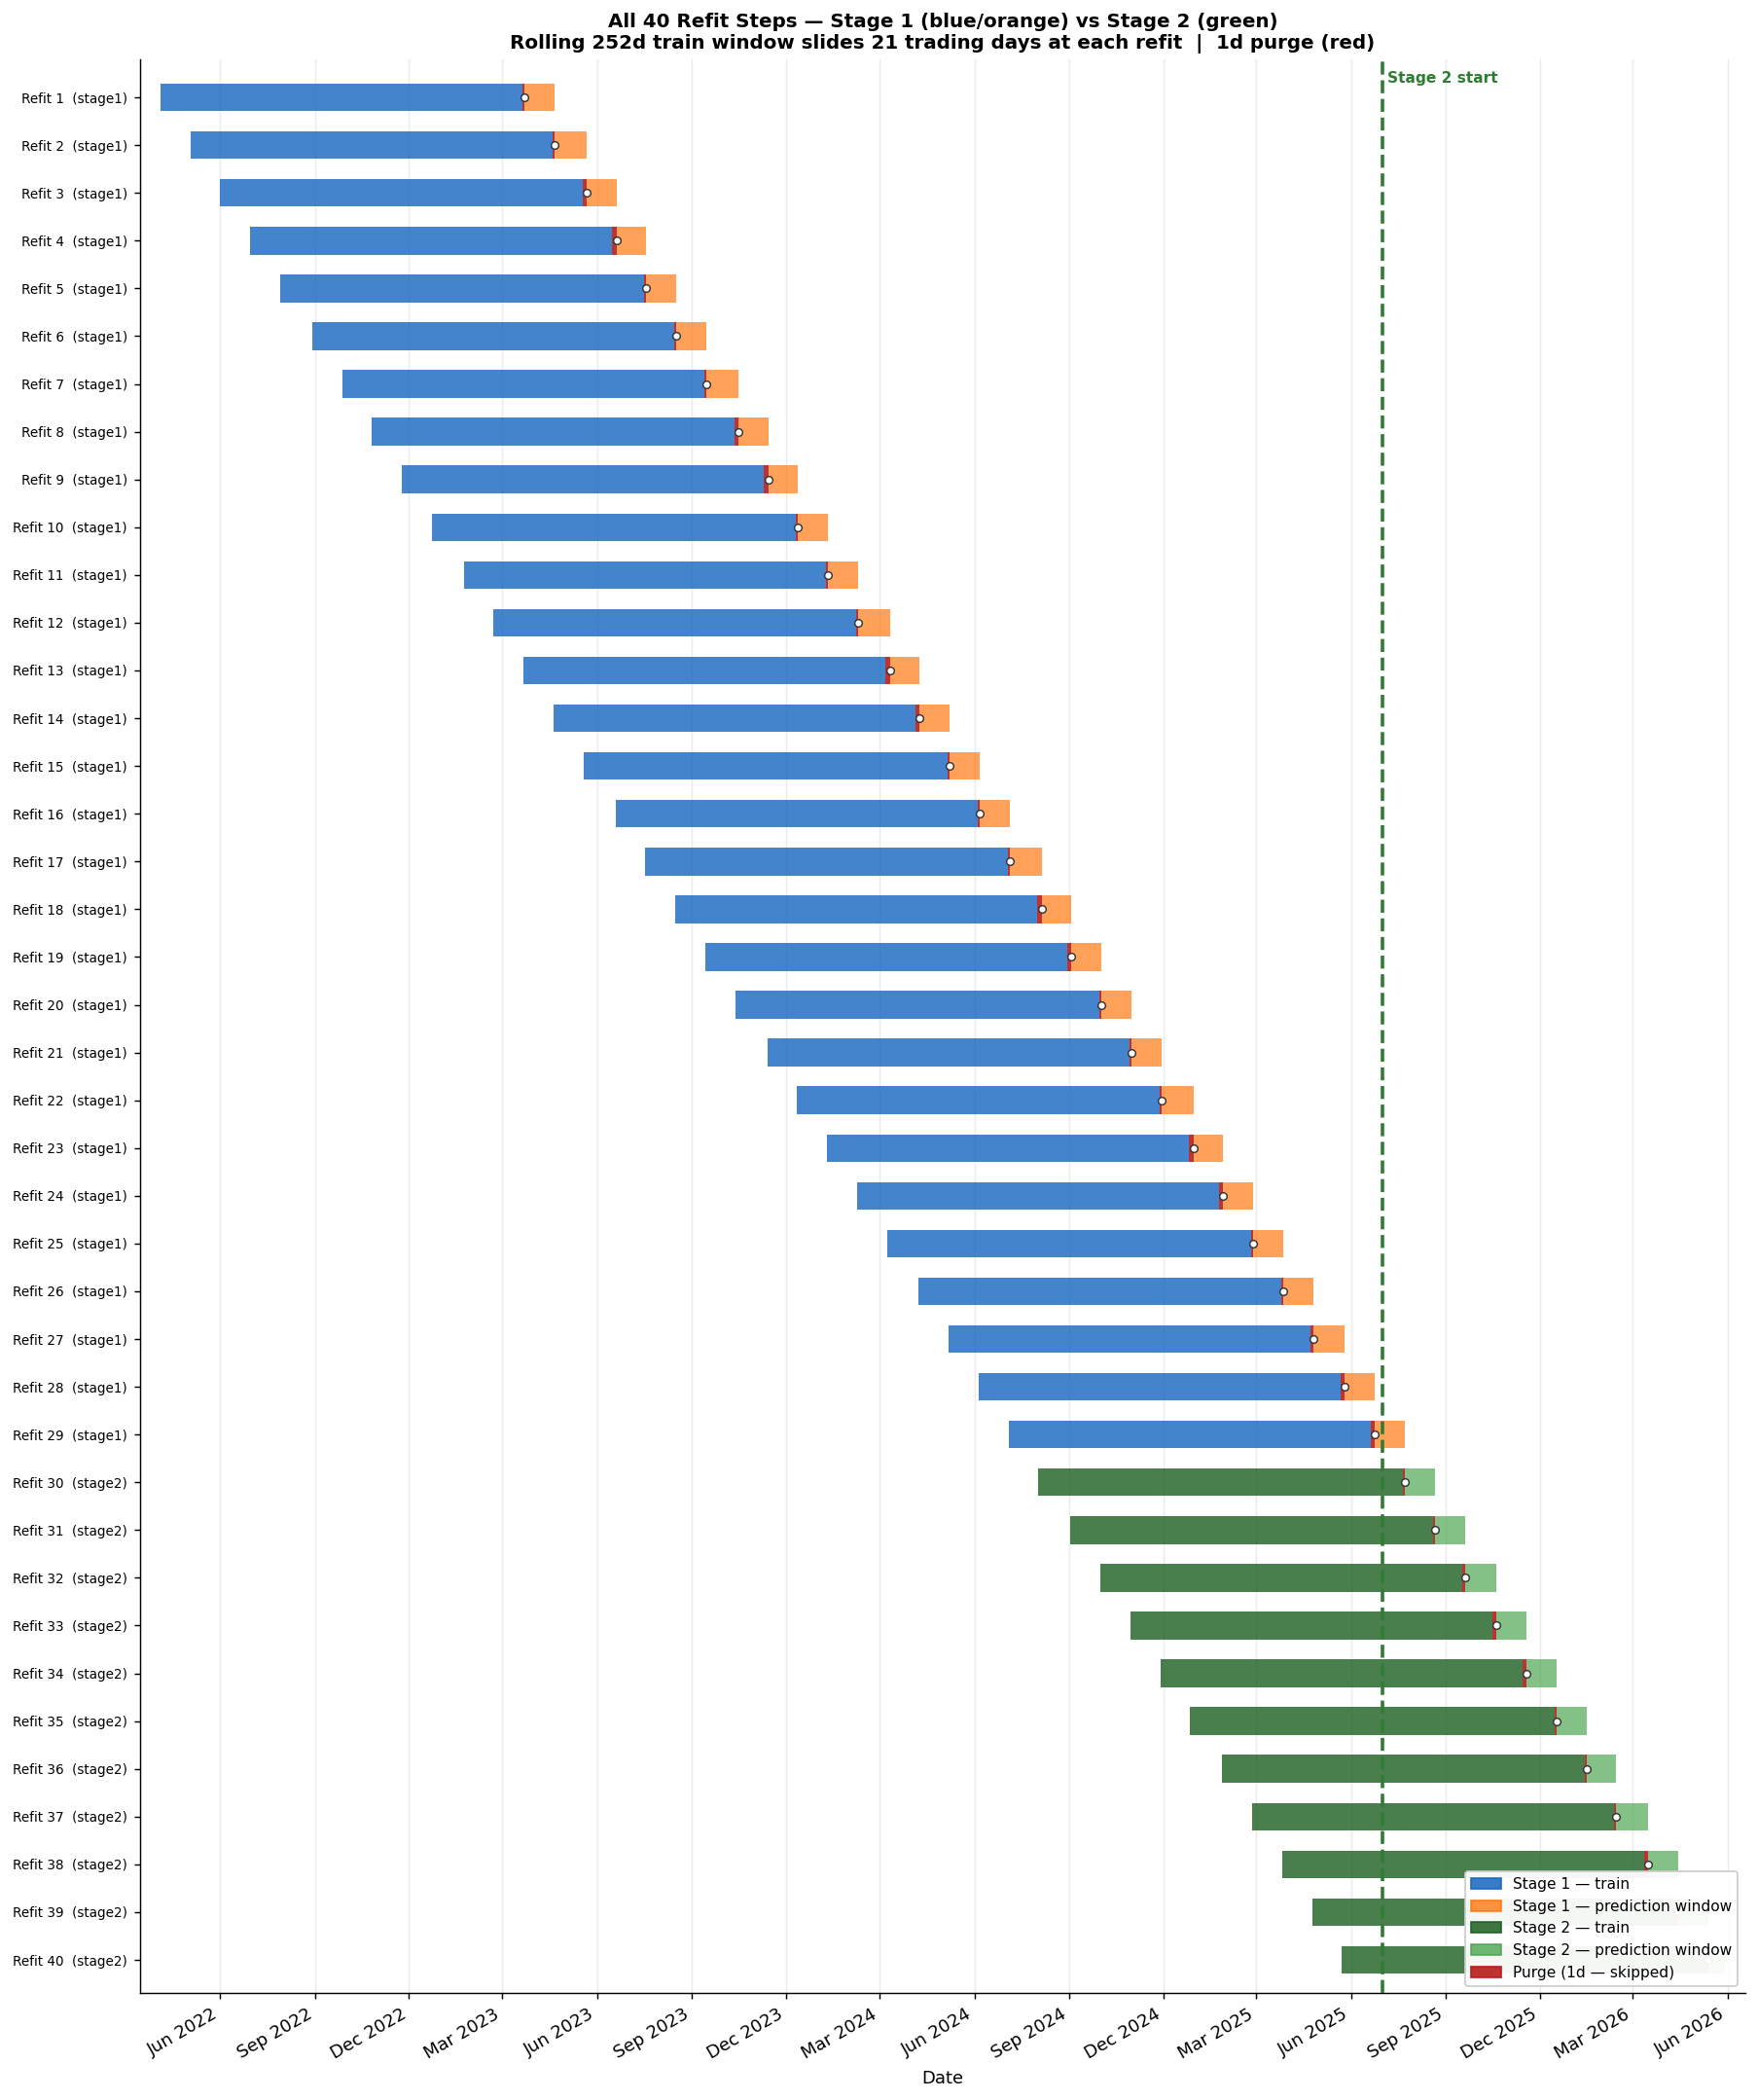

In [5]:
COLORS = {
    'stage1': {'train': '#1565C0', 'pred': '#FF6F00'},   # blue train / orange pred
    'stage2': {'train': '#1B5E20', 'pred': '#43A047'},   # dark-green train / light-green pred
}

all_refits = refits.reset_index(drop=True)
N = len(all_refits)

fig, ax = plt.subplots(figsize=(14, N * 0.38 + 1.5))
H = 0.58

for i, row in all_refits.iterrows():
    y = N - i
    c_tr = COLORS[row.stage]['train']
    c_pr = COLORS[row.stage]['pred']

    # ── Rolling training bar (constant width) ─────────────────────────────
    ax.barh(y, width=(row.train_end - row.train_start).days,
            left=row.train_start, height=H, color=c_tr, alpha=0.80, zorder=2)

    # ── Purge strip (1 day between train end and test date) ───────────────
    purge_width = (row.test_date - row.train_end).days
    ax.barh(y, width=purge_width, left=row.train_end,
            height=H, color='#B71C1C', alpha=0.90, zorder=3)

    # ── Prediction window: this refit's test_date → next refit ────────────
    next_refit_date = (all_refits.iloc[i + 1].test_date
                       if i < N - 1 else pd.Timestamp(dates_np[-1]))
    pred_width = (next_refit_date - row.test_date).days
    ax.barh(y, width=pred_width, left=row.test_date,
            height=H, color=c_pr, alpha=0.65, zorder=2)

    # ── Refit marker ──────────────────────────────────────────────────────
    ax.scatter([row.test_date], [y], color='white', s=18, zorder=5,
               linewidths=0.8, edgecolors='#333')

# ── Stage 2 divider ───────────────────────────────────────────────────────────
ax.axvline(STAGE2_START, color='#2E7D32', lw=2, ls='--', zorder=4)
ax.text(STAGE2_START + pd.Timedelta(days=5), N + 0.3,
        'Stage 2 start', fontsize=8.5, color='#2E7D32', fontweight='bold')

# ── Y-axis labels ─────────────────────────────────────────────────────────────
ax.set_ylim(0.3, N + 0.8)
ax.set_yticks(range(1, N + 1))
ax.set_yticklabels(
    [f'Refit {N - i}  ({all_refits.iloc[N - 1 - i].stage})'
     for i in range(N)],
    fontsize=7.5)

# ── X-axis ────────────────────────────────────────────────────────────────────
ax.set_xlim(all_refits.iloc[0].train_start - pd.Timedelta(days=20),
            pd.Timestamp(dates_np[-1]) + pd.Timedelta(days=20))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.grid(axis='x', alpha=0.25)
ax.set_xlabel('Date')
ax.set_title(
    f'All {N} Refit Steps — Stage 1 (blue/orange) vs Stage 2 (green)\n'
    f'Rolling {ROLLING_WINDOW}d train window slides {REFIT_EVERY} trading days at each refit  |  '
    f'{PURGE_DAYS}d purge (red)',
    fontsize=11, fontweight='bold')

patches = [
    mpatches.Patch(color=COLORS['stage1']['train'], alpha=0.85, label='Stage 1 — train'),
    mpatches.Patch(color=COLORS['stage1']['pred'],  alpha=0.75, label='Stage 1 — prediction window'),
    mpatches.Patch(color=COLORS['stage2']['train'], alpha=0.85, label='Stage 2 — train'),
    mpatches.Patch(color=COLORS['stage2']['pred'],  alpha=0.75, label='Stage 2 — prediction window'),
    mpatches.Patch(color='#B71C1C', alpha=0.90, label=f'Purge ({PURGE_DAYS}d — skipped)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=8.5, framealpha=0.95)
plt.tight_layout()
plt.savefig('../output/figures/splitter_windows.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3 — Refit Cycle Zoom (two consecutive refits)

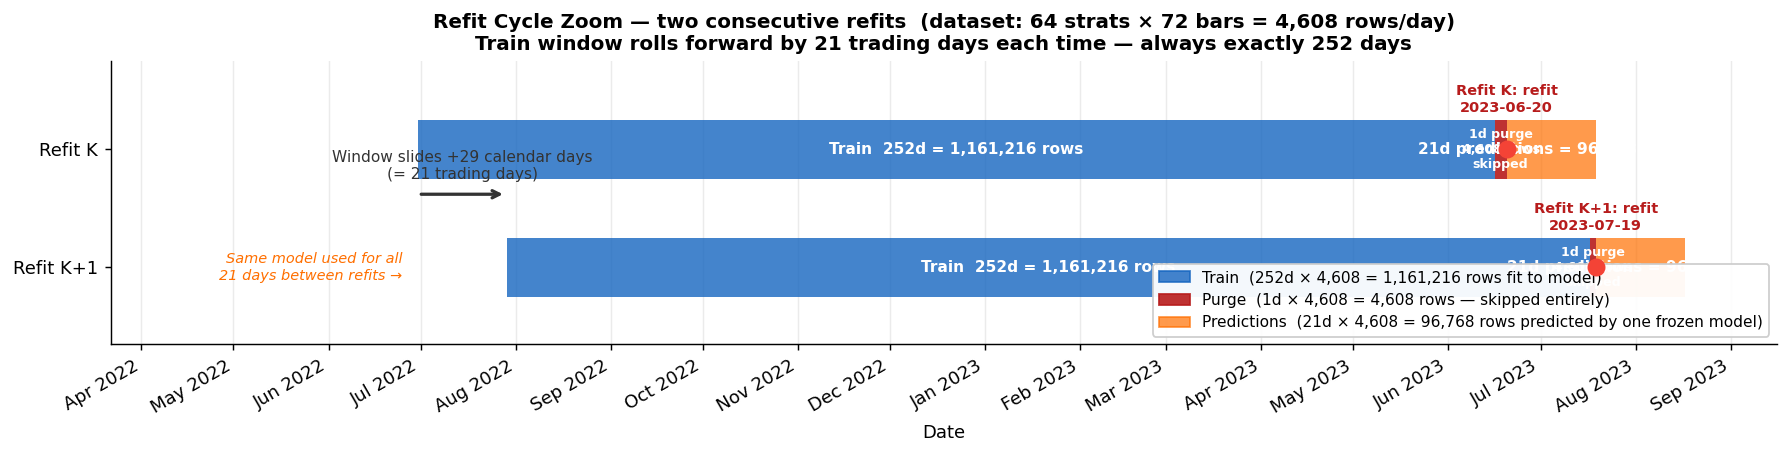

In [6]:
# ── Pick two consecutive Stage 1 refits (step 3 and 4) ───────────────────────
s1_refits = refits[refits.stage == 'stage1'].reset_index(drop=True)
r0, r1 = s1_refits.iloc[3], s1_refits.iloc[4]

fig, ax = plt.subplots(figsize=(14, 3.6))
y0, y1 = 2, 1
H = 0.50

def hbar(ax, start, end, color, alpha, label, y, h, fontsize=8.5):
    w = (end - start).days
    ax.barh(y, width=w, left=start, height=h, color=color, alpha=alpha, zorder=2)
    mid = start + (end - start) / 2
    ax.text(mid, y, label, va='center', ha='center', fontsize=fontsize,
            color='white', fontweight='bold', zorder=5)

for y, r, next_r in [(y0, r0, r1), (y1, r1, s1_refits.iloc[5])]:
    label_y = 'Refit K' if y == y0 else 'Refit K+1'

    # Train (blue)
    hbar(ax, r.train_start, r.train_end,
         '#1565C0', 0.80,
         f'Train  {r.n_train_days}d = {r.n_train_days*RPD:,} rows', y, H)

    # Purge (red)
    hbar(ax, r.train_end, r.test_date,
         '#B71C1C', 0.90,
         f'{PURGE_DAYS}d purge\n{PURGE_DAYS*RPD:,} rows\nskipped', y, H, fontsize=7)

    # Prediction window (orange): test_date → next refit test_date
    hbar(ax, r.test_date, next_r.test_date,
         '#FF6F00', 0.70,
         f'{REFIT_EVERY}d predictions = {REFIT_EVERY*RPD:,} rows', y, H)

    # Refit dot
    ax.scatter([r.test_date], [y], color='#F44336', s=80, zorder=6)
    ax.text(r.test_date, y + 0.32, f'{label_y}: refit\n{r.test_date.date()}',
            ha='center', fontsize=8, color='#B71C1C', fontweight='bold')

# ── Arrow showing window shift between the two refits ────────────────────────
shift_days = (r1.train_start - r0.train_start).days
ax.annotate('', xy=(r1.train_start, 1.62), xytext=(r0.train_start, 1.62),
            arrowprops=dict(arrowstyle='->', color='#333', lw=1.8))
ax.text(r0.train_start + (r1.train_start - r0.train_start)/2, 1.72,
        f'Window slides +{shift_days} calendar days\n(= {REFIT_EVERY} trading days)',
        ha='center', va='bottom', fontsize=8.5, color='#333')

# ── Key insight box ───────────────────────────────────────────────────────────
ax.text(r0.train_start - pd.Timedelta(days=5), 1.0,
        'Same model used for all\n21 days between refits →',
        va='center', ha='right', fontsize=8, color='#FF6F00',
        style='italic')

ax.set_xlim(r0.train_start - pd.Timedelta(days=100),
            s1_refits.iloc[5].test_date + pd.Timedelta(days=30))
ax.set_ylim(0.35, 2.75)
ax.set_yticks([y0, y1])
ax.set_yticklabels(['Refit K', 'Refit K+1'], fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.grid(axis='x', alpha=0.25)
ax.set_xlabel('Date')
ax.set_title(
    f'Refit Cycle Zoom — two consecutive refits  '
    f'(dataset: {N_STRATS} strats × {N_BARS} bars = {RPD:,} rows/day)\n'
    f'Train window rolls forward by {REFIT_EVERY} trading days each time — always exactly {ROLLING_WINDOW} days',
    fontsize=11, fontweight='bold')

patches = [
    mpatches.Patch(color='#1565C0', alpha=0.8,
                   label=f'Train  ({ROLLING_WINDOW}d × {RPD:,} = {ROLLING_WINDOW*RPD:,} rows fit to model)'),
    mpatches.Patch(color='#B71C1C', alpha=0.9,
                   label=f'Purge  ({PURGE_DAYS}d × {RPD:,} = {PURGE_DAYS*RPD:,} rows — skipped entirely)'),
    mpatches.Patch(color='#FF6F00', alpha=0.7,
                   label=f'Predictions  ({REFIT_EVERY}d × {RPD:,} = {REFIT_EVERY*RPD:,} rows predicted by one frozen model)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=8.5, framealpha=0.95)
plt.tight_layout()
plt.savefig('../output/figures/splitter_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4 — Combined thesis figure: Protocol Overview + Rolling Window Mechanics

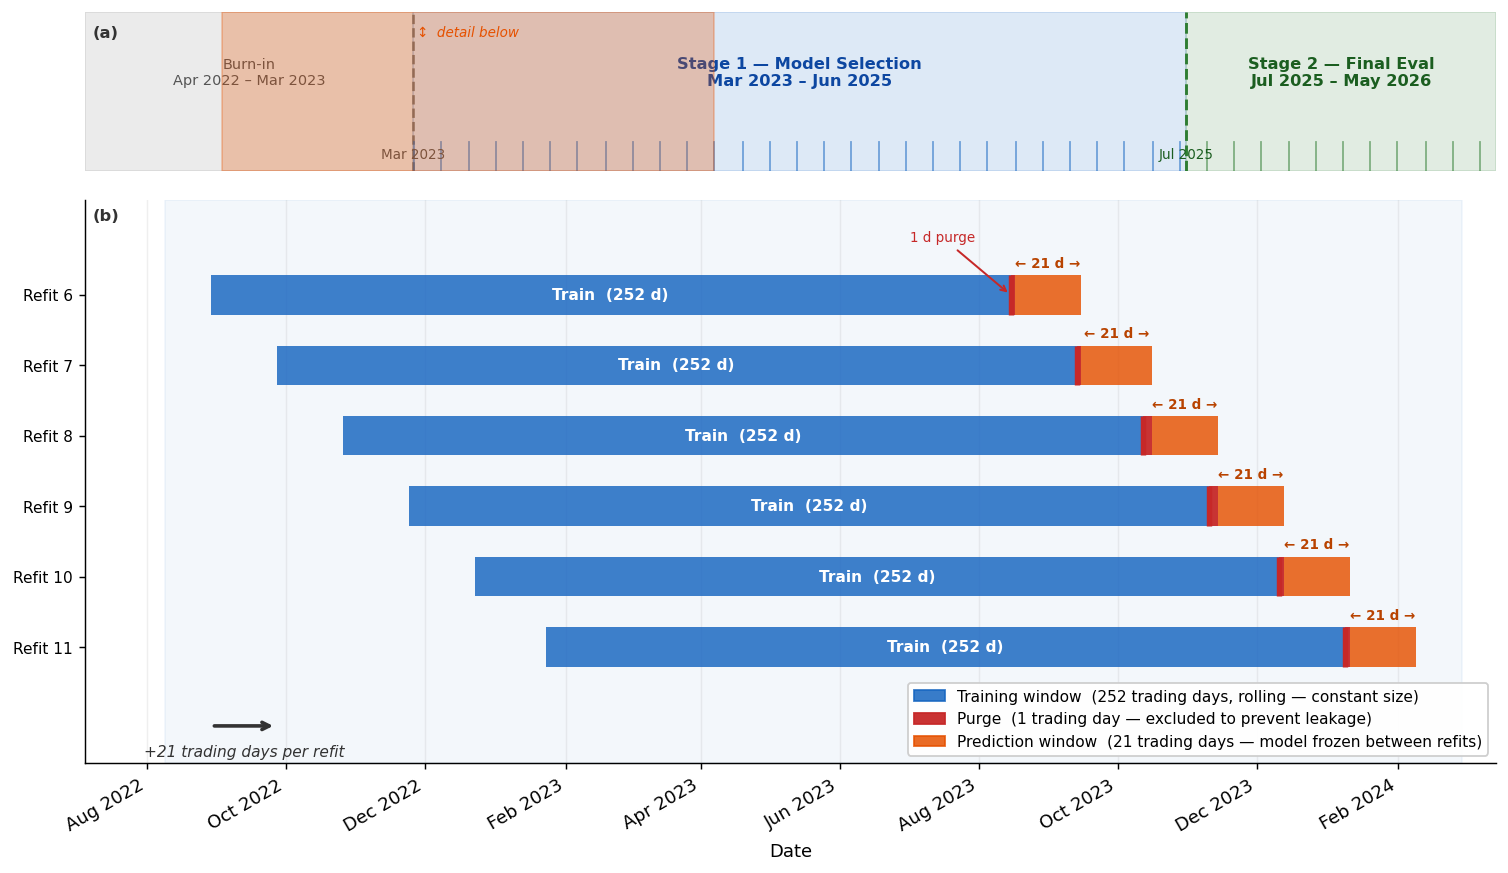

Saved: splitter_combined.pdf  +  splitter_combined.png


In [8]:

import matplotlib.gridspec as gridspec

ACCENT = '#E65100'

fig = plt.figure(figsize=(14, 7.5))
gs  = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[0.9, 3.2], hspace=0.08)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

burn_end = df.test_date.min() - pd.Timedelta(days=1)

# ─── 6 consecutive Stage-1 refits for the zoom ───────────────────────────────
s1_df = refits[refits.stage == 'stage1'].reset_index(drop=True)
s2_df = refits[refits.stage == 'stage2'].reset_index(drop=True)
ZOOM_START_IDX = 5
ZOOM_N         = 6
zoom_refits = s1_df.iloc[ZOOM_START_IDX : ZOOM_START_IDX + ZOOM_N].reset_index(drop=True)
z_start     = zoom_refits.iloc[0].train_start
z_end       = s1_df.iloc[ZOOM_START_IDX + ZOOM_N].test_date

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL A — Phase Timeline
# ═══════════════════════════════════════════════════════════════════════════════
ax1.axvspan(DATA_START,   burn_end,     alpha=0.14, color='#757575')
ax1.axvspan(burn_end,     STAGE2_START, alpha=0.14, color='#1565C0')
ax1.axvspan(STAGE2_START, DATA_END,     alpha=0.14, color='#2E7D32')

ax1.axvline(burn_end,     color='#757575', lw=1.4, ls='--')
ax1.axvline(STAGE2_START, color='#2E7D32', lw=1.6, ls='--')

for _, row in refits.iterrows():
    col = '#2E7D32' if row.stage == 'stage2' else '#1565C0'
    ax1.axvline(row.test_date, ymin=0, ymax=0.18, color=col, lw=1.0, alpha=0.55)

# Zoom highlight
ax1.axvspan(z_start, z_end, alpha=0.28, color=ACCENT, zorder=5)
ax1.text(z_start + (z_end - z_start) / 2, 0.92,
         '↕  detail below', ha='center', va='top',
         fontsize=7.5, color=ACCENT, style='italic', zorder=6)

# Phase labels — use date ranges
s1_start_lbl = df[df.stage=='stage1'].test_date.min().strftime('%b %Y')
s1_end_lbl   = df[df.stage=='stage1'].test_date.max().strftime('%b %Y')
s2_start_lbl = df[df.stage=='stage2'].test_date.min().strftime('%b %Y')
s2_end_lbl   = df[df.stage=='stage2'].test_date.max().strftime('%b %Y')
bi_start_lbl = DATA_START.strftime('%b %Y')
bi_end_lbl   = burn_end.strftime('%b %Y')

ax1.text(DATA_START + (burn_end - DATA_START)/2, 0.62,
         f'Burn-in\n{bi_start_lbl} – {bi_end_lbl}',
         ha='center', va='center', fontsize=8, color='#555')
ax1.text(burn_end + (STAGE2_START - burn_end)/2, 0.62,
         f'Stage 1 — Model Selection\n{s1_start_lbl} – {s1_end_lbl}',
         ha='center', va='center', fontsize=9, color='#0D47A1', fontweight='bold')
ax1.text(STAGE2_START + (DATA_END - STAGE2_START)/2, 0.62,
         f'Stage 2 — Final Eval\n{s2_start_lbl} – {s2_end_lbl}',
         ha='center', va='center', fontsize=9, color='#1B5E20', fontweight='bold')

for xv, lbl, col in [(burn_end,     burn_end.strftime('%b %Y'),     '#555'),
                     (STAGE2_START, STAGE2_START.strftime('%b %Y'), '#1B5E20')]:
    ax1.text(xv, 0.06, lbl, ha='center', va='bottom', fontsize=7.5, color=col)

ax1.text(0.005, 0.92, '(a)', transform=ax1.transAxes,
         fontsize=9, fontweight='bold', va='top', color='#333')
ax1.set_xlim(DATA_START, DATA_END)
ax1.set_ylim(0, 1)
ax1.set_yticks([])
ax1.set_xticks([])
for s in ax1.spines.values():
    s.set_visible(False)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL B — Rolling Window Mechanics
# ═══════════════════════════════════════════════════════════════════════════════
NZ = len(zoom_refits)
H  = 0.56

ax2.axvspan(z_start - pd.Timedelta(days=20),
            z_end   + pd.Timedelta(days=20),
            alpha=0.05, color='#1565C0')

for i, row in zoom_refits.iterrows():
    y         = NZ - i
    next_test = (zoom_refits.iloc[i+1].test_date if i < NZ-1
                 else s1_df.iloc[ZOOM_START_IDX + ZOOM_N].test_date)

    # Train bar
    tr_w   = (row.train_end - row.train_start).days
    tr_mid = row.train_start + (row.train_end - row.train_start) / 2
    ax2.barh(y, width=tr_w, left=row.train_start, height=H,
             color='#1565C0', alpha=0.82, zorder=2)
    ax2.text(tr_mid, y, 'Train  (252 d)',
             ha='center', va='center', fontsize=8.5,
             color='white', fontweight='bold', zorder=5)

    # Purge: draw as actual width (1-2 calendar days) + vertical accent line
    pu_w = (row.test_date - row.train_end).days
    ax2.barh(y, width=pu_w, left=row.train_end, height=H,
             color='#C62828', alpha=0.95, zorder=3)
    # Thick red line at the train/purge boundary for visibility
    ax2.vlines(row.train_end, y - H/2, y + H/2,
               colors='#C62828', lw=3, zorder=4)

    # Prediction window
    pr_w   = (next_test - row.test_date).days
    pr_mid = row.test_date + (next_test - row.test_date) / 2
    ax2.barh(y, width=pr_w, left=row.test_date, height=H,
             color='#E65100', alpha=0.82, zorder=2)
    # Label above the prediction bar
    ax2.text(pr_mid, y + H/2 + 0.07, '← 21 d →',
             ha='center', va='bottom', fontsize=7.5,
             color='#B84300', fontweight='bold', zorder=5)

# Purge annotation on top row
r0 = zoom_refits.iloc[0]
ax2.annotate(
    '1 d purge',
    xy=(r0.train_end, NZ),
    xytext=(r0.train_end - pd.Timedelta(days=30), NZ + 0.76),
    fontsize=7.5, color='#C62828', ha='center',
    arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.1))

# Arrow showing +21-day window shift
r0_ts = zoom_refits.iloc[0].train_start
r1_ts = zoom_refits.iloc[1].train_start
y_arr = -0.12
ax2.annotate('', xy=(r1_ts, y_arr), xytext=(r0_ts, y_arr),
             arrowprops=dict(arrowstyle='->', color='#333', lw=2.0))
ax2.text(r0_ts + (r1_ts - r0_ts) / 2, y_arr - 0.26,
         '+21 trading days per refit',
         ha='center', va='top', fontsize=8.5, color='#333', style='italic')

# Y-axis
start_refit = ZOOM_START_IDX + 1
ax2.set_yticks(range(1, NZ + 1))
ax2.set_yticklabels(
    [f'Refit {start_refit + NZ - 1 - j}' for j in range(NZ)],
    fontsize=8.5)

x_left  = z_start - pd.Timedelta(days=55)
x_right = z_end   + pd.Timedelta(days=35)
ax2.set_xlim(x_left, x_right)
ax2.set_ylim(-0.65, NZ + 1.35)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.grid(axis='x', alpha=0.2)
ax2.set_xlabel('Date')

ax2.text(0.005, 0.985, '(b)', transform=ax2.transAxes,
         fontsize=9, fontweight='bold', va='top', color='#333')

patches = [
    mpatches.Patch(color='#1565C0', alpha=0.85,
                   label='Training window  (252 trading days, rolling — constant size)'),
    mpatches.Patch(color='#C62828', alpha=0.95,
                   label='Purge  (1 trading day — excluded to prevent leakage)'),
    mpatches.Patch(color='#E65100', alpha=0.85,
                   label='Prediction window  (21 trading days — model frozen between refits)'),
]
ax2.legend(handles=patches, loc='lower right', fontsize=8.5, framealpha=0.95)

'''fig.suptitle(
    'Walk-Forward Validation: Protocol Overview (a) and Rolling Window Mechanics (b)',
    fontsize=12, fontweight='bold', y=1.01)
'''
plt.savefig('../output/figures/splitter_combined.pdf', bbox_inches='tight')
plt.savefig('../output/figures/splitter_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: splitter_combined.pdf  +  splitter_combined.png')
